# Quantum Bound States: Shooting, Matrix, and Variational Methods

Square-well eigenstates with a central barrier, plus Lennard–Jones bound states from finite-difference diagonalization and stochastic variation.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.



Single square well: V = 0 in [-1,1], V = 1e5 outside

Even parity states:
   state          E_numeric         E_infinite             DeltaE
      e0       1.2282014569       1.2337005501      -0.0054990932
      e1      11.0537938797      11.1033049512      -0.0495110715
      e2      30.7048761519      30.8425137534      -0.1376376015
      e3      60.1812431275      60.4513269567      -0.2700838292

Odd parity states:
   state          E_numeric         E_infinite             DeltaE
      o1       4.9128026222       4.9348022005      -0.0219995783
      o2      19.6511592022      19.7392088022      -0.0880496000
      o3      44.2149158800      44.4132198049      -0.1983039249
      o4      78.6038162244      78.9568352087      -0.3530189843


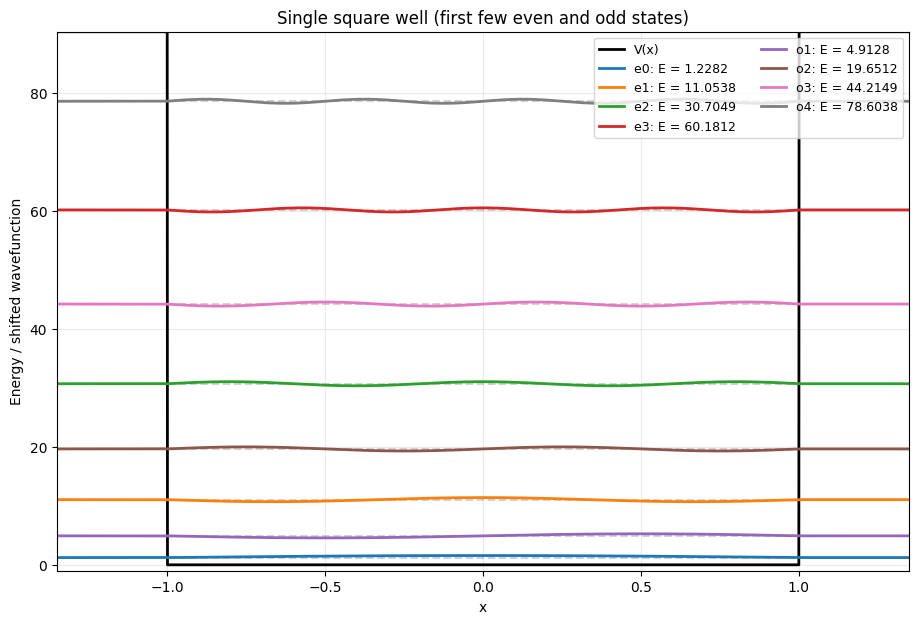


Square well with central barrier: V2 = 100.0 on [-0.2,0.2]

Even parity states:
   state          E_numeric         E_infinite             DeltaE
      e0       6.4631218206       1.2337005501       5.2294212705
      e1      25.6753818481      11.1033049512      14.5720768969
      e2      56.8254365560      30.8425137534      25.9829228025
      e3      95.8861004802      60.4513269567      35.4347735235

Odd parity states:
   state          E_numeric         E_infinite             DeltaE
      o1       6.4799211552       4.9348022005       1.5451189547
      o2      25.7824210035      19.7392088022       6.0432122013
      o3      57.3925014979      44.4132198049      12.9792816930
      o4      99.9438660453      78.9568352087      20.9870308366


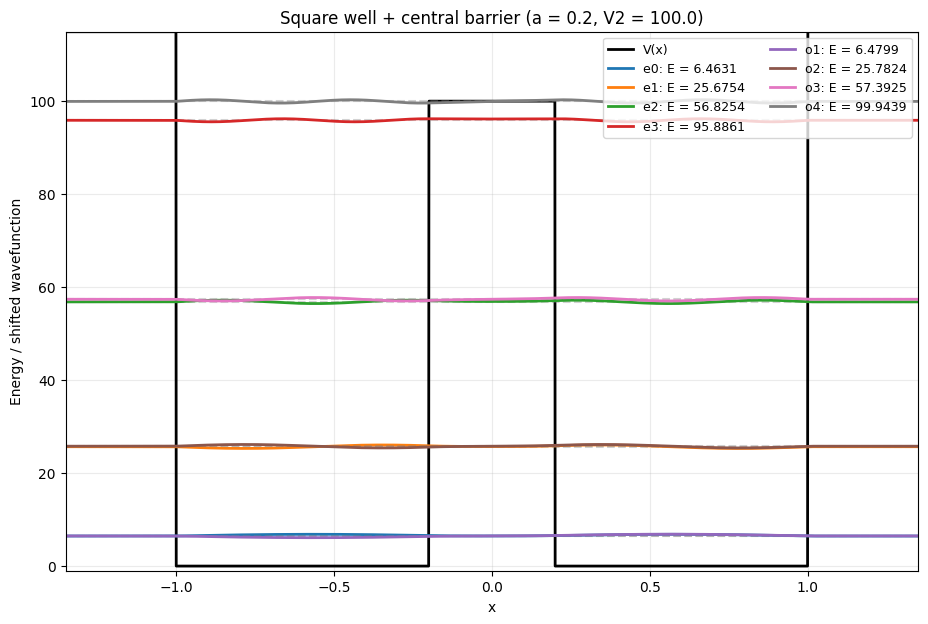


Energy shifts caused by the central barrier

Even parity states:
   state           E_single          E_barrier              shift
      e0       1.2282014569       6.4631218206       5.2349203637
      e1      11.0537938797      25.6753818481      14.6215879684
      e2      30.7048761519      56.8254365560      26.1205604041
      e3      60.1812431275      95.8861004802      35.7048573527

Odd parity states:
   state           E_single          E_barrier              shift
      o1       4.9128026222       6.4799211552       1.5671185330
      o2      19.6511592022      25.7824210035       6.1312618013
      o3      44.2149158800      57.3925014979      13.1775856179
      o4      78.6038162244      99.9438660453      21.3400498209


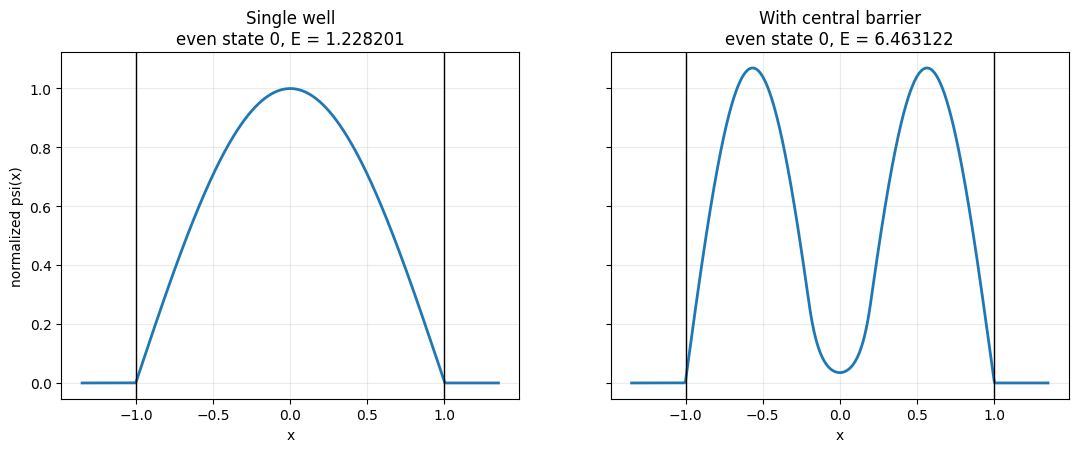

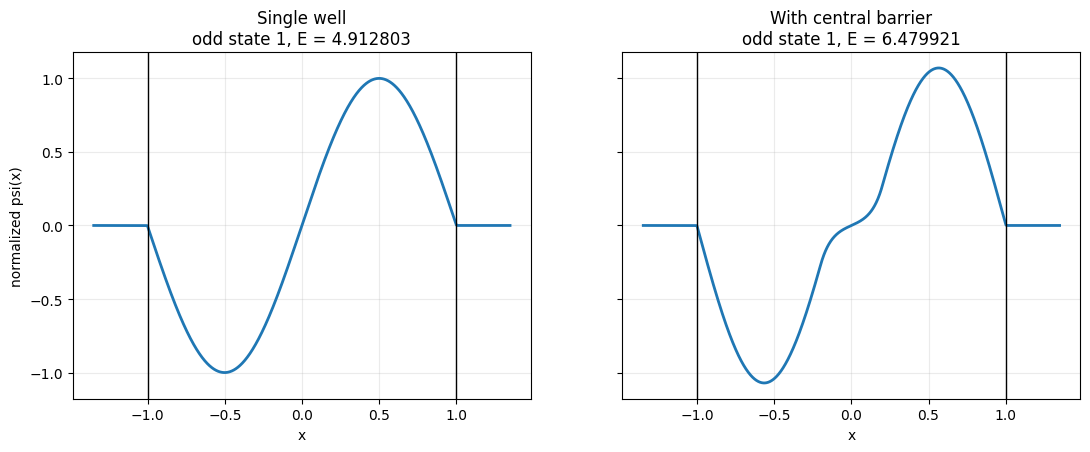

In [ ]:
# Lab 13 - Task 1

import numpy as np;
import matplotlib.pyplot as plt;

# Parameters

Vmax = 1.0e5;          # outer wall height
dx = 0.001;            # spatial step on [0,1]
n_states_each = 4;     # number of even and odd states to find
# energy search
scan_step = 0.10;      # coarse scan step for bracketing roots
bisect_tol = 1e-12;    # bisection tolerance
max_bisect_iter = 200;
E_scan_max = 200.0;    # enough for first few states here
# central barrier case
a_barrier = 0.20;
V2_barrier = 100.0;
x_tail = 0.35;         # plot out to x = ±(1 + x_tail)
# wavefunction plotting scale when shifted by energy
psi_scale_single = 0.35;
psi_scale_barrier = 0.35;


# Potential calc
def calculateV(x, Vmax, a = 0.0, V2 = 0.0):
    x = np.asarray(x);
    V = np.where(np.abs(x) >= 1.0, Vmax, 0.0);
    if a > 0:
        V = np.where(np.abs(x) <= a, V2, V);
        V = np.where(np.abs(x) >= 1.0, Vmax, V);  # keep outer walls
    return V


# Integrate the Schrodinger equation on x in [0,1].
def shoot_inside(E, parity, dx, Vmax, a = 0.0, V2 = 0.0):
    N = int(round(1.0 / dx));
    xh = np.linspace(0.0, 1.0, N + 1)
    psi = np.zeros(N + 1, dtype = float);
    # even: psi(0)=1, psi'(0)=0  => psi(dx)=psi(0) + O(dx^2) & odd : psi(0)=0, psi'(0)=1  => psi(dx)=dx + O(dx^3)
    V0 = float(calculateV(np.array([0.0]), Vmax, a, V2)[0]);

    if parity == +1:
        psi[0] = 1.0;
        psi[1] = psi[0] + 0.5 * dx**2 * 2.0 * (V0 - E) * psi[0];
    elif parity == -1:
        psi[0] = 0.0;
        psi[1] = dx;   # because psi'(0)=1
    else:
        raise ValueError("parity must be +1 (even) or -1 (odd)");

    # Finite-difference propagation: psi_{i+1} = 2 psi_i - psi_{i-1} + 2 dx^2 (V_i - E) psi_i
    for i in range(1, N):
        Vi = float(calculateV(np.array([xh[i]]), Vmax, a, V2)[0]);
        psi[i + 1] = (2.0 * psi[i] - psi[i - 1] + 2.0 * dx**2 * (Vi - E) * psi[i]);

    # Count nodes in (0,1)
    nodes = 0;
    eps = 1e-12 * max(1.0, np.max(np.abs(psi)));
    prev_sign = 0;
    for val in psi[1:-1]:
        if abs(val) < eps:
            continue;
        s = 1 if val > 0 else -1
        if prev_sign == 0:
            prev_sign = s;
        elif s != prev_sign:
            nodes += 1;
            prev_sign = s;

    # Matching to outside exponential tail at x = 1: psi_out ~ A exp[-kappa (x-1)], with kappa = sqrt(2(Vmax-E)) so psi'(1) + kappa psi(1) = 0
    if E >= Vmax:
        residual = np.nan;
    else:
        kappa = np.sqrt(2.0 * (Vmax - E));
        # second-order backward derivative at x = 1
        dpsi = (3.0 * psi[-1] - 4.0 * psi[-2] + psi[-3]) / (2.0 * dx);
        residual = dpsi + kappa * psi[-1];

    return xh, psi, residual, nodes;


# Residual wrapper
def residual(E, parity, dx, Vmax, a = 0.0, V2 = 0.0):
    _, _, r, _ = shoot_inside(E, parity, dx, Vmax, a, V2);
    return r;


# Bisection
def bisect_root(E1, E2, parity, dx, Vmax, a = 0.0, V2 = 0.0, tol = 1e-12, max_iter = 200):
    f1 = residual(E1, parity, dx, Vmax, a, V2);
    f2 = residual(E2, parity, dx, Vmax, a, V2);

    if not (np.isfinite(f1) and np.isfinite(f2)):
        raise ValueError("Non-finite residual in bisection bracket.");

    if f1 == 0.0:
        return E1;
    if f2 == 0.0:
        return E2;
    if f1 * f2 > 0.0:
        raise ValueError("Bracket does not straddle a root.");

    left, right = E1, E2
    fl, fr = f1, f2;

    for _ in range(max_iter):
        mid = 0.5 * (left + right);
        fm = residual(mid, parity, dx, Vmax, a, V2);
        if not np.isfinite(fm):
            raise ValueError("Non-finite residual encountered in bisection.");

        if abs(right - left) < tol or fm == 0.0:
            return mid;

        if fl * fm < 0.0:
            right, fr = mid, fm;
        else:
            left, fl = mid, fm;
    #endfor
    return 0.5 * (left + right);


# Find eigenvalues by scanning for residual sign flips
def find_eigenvalues(parity, n_states, dx, Vmax, a = 0.0, V2 = 0.0, scan_step = 0.1, E_scan_max = 200.0, tol = 1e-12, max_bisect_iter = 200):
    eigs = [];
    E_prev = 1e-8;
    f_prev = residual(E_prev, parity, dx, Vmax, a, V2);

    E = E_prev + scan_step;
    while E <= min(E_scan_max, Vmax - 1e-8) and len(eigs) < n_states:
        f_now = residual(E, parity, dx, Vmax, a, V2);

        if np.isfinite(f_prev) and np.isfinite(f_now):
            if f_prev == 0.0:
                root = E_prev;
                if len(eigs) == 0 or abs(root - eigs[-1]) > 1e-8:
                    eigs.append(root);
            elif f_prev * f_now < 0.0:
                root = bisect_root(E_prev, E, parity, dx, Vmax, a, V2, tol = tol, max_iter = max_bisect_iter);
                if len(eigs) == 0 or abs(root - eigs[-1]) > 1e-8:
                    eigs.append(root);

                # jump a bit forward so we do not rediscover the same root
                E = root + 0.5 * scan_step;
                f_now = residual(E, parity, dx, Vmax, a, V2);

        E_prev, f_prev = E, f_now;
        E += scan_step;
    #endwhile
    return eigs;

# -----------------------------
# Build full normalized wavefunction with analytic outer tails
# -----------------------------
def build_full_wavefunction(E, parity, dx, Vmax, a = 0.0, V2 = 0.0, x_tail = 0.35):
    xh, psi_in, _, nodes = shoot_inside(E, parity, dx, Vmax, a, V2);
    # Analytic tail for x >= 1
    if E >= Vmax:
        raise ValueError("Bound-state construction requires E < Vmax.");

    kappa = np.sqrt(2.0 * (Vmax - E));
    Nt = int(round(x_tail / dx));
    xt = 1.0 + np.arange(1, Nt + 1) * dx;
    psi_t = psi_in[-1] * np.exp(-kappa * (xt - 1.0));
    # Right half: [0,1] plus tail
    x_right = np.concatenate([xh, xt]);
    psi_right = np.concatenate([psi_in, psi_t]);
    # Left half from parity
    x_left = -x_right[1:][::-1];
    if parity == +1:
        psi_left = psi_right[1:][::-1];
    else:
        psi_left = -psi_right[1:][::-1];

    x_full = np.concatenate([x_left, x_right]);
    psi_full = np.concatenate([psi_left, psi_right]);

    # normalize
    norm = np.sqrt(np.trapezoid(psi_full**2, x_full));
    psi_full /= norm;

    return x_full, psi_full, nodes;


# Solve and store states
def solve_states(n_states_each, dx, Vmax, a = 0.0, V2 = 0.0, scan_step = 0.1, E_scan_max = 200.0, tol = 1e-12,
                 max_bisect_iter = 200, x_tail = 0.35):
    even_E = find_eigenvalues(+1, n_states_each, dx, Vmax, a, V2, scan_step, E_scan_max, tol, max_bisect_iter);
    odd_E  = find_eigenvalues(-1, n_states_each, dx, Vmax, a, V2, scan_step, E_scan_max, tol, max_bisect_iter);
    states = {"even": [], "odd": []};

    for E in even_E:
        x, psi, nodes = build_full_wavefunction(E, +1, dx, Vmax, a, V2, x_tail);
        states["even"].append({ "E": E, "x": x, "psi": psi, "nodes_right_half": nodes});
    #endfor
    for E in odd_E:
        x, psi, nodes = build_full_wavefunction(E, -1, dx, Vmax, a, V2, x_tail);
        states["odd"].append({"E": E,"x": x, "psi": psi, "nodes_right_half": nodes});
    #endfor
    return states;

# Infinite-well exact energies on [-1,1]
def E_inf_even(n):
    return ((2*n + 1)**2 * np.pi**2) / 8.0;

def E_inf_odd(n):
    return (n**2 * np.pi**2) / 2.0;


# Printing tables
def print_energy_table(states, title):
    print("\n" + "="*78);
    print(title);
    print("="*78);
    print("\nEven parity states:");
    print(f"{'state':>8s} {'E_numeric':>18s} {'E_infinite':>18s} {'DeltaE':>18s}");
    for i, st in enumerate(states["even"]):
        E_num = st["E"];
        E_ex = E_inf_even(i);
        print(f"{('e'+str(i)):>8s} {E_num:18.10f} {E_ex:18.10f} {E_num - E_ex:18.10f}");
    #endfor
    print("\nOdd parity states:");
    print(f"{'state':>8s} {'E_numeric':>18s} {'E_infinite':>18s} {'DeltaE':>18s}");
    for i, st in enumerate(states["odd"], start = 1):
        E_num = st["E"];
        E_ex = E_inf_odd(i);
        print(f"{('o'+str(i)):>8s} {E_num:18.10f} {E_ex:18.10f} {E_num - E_ex:18.10f}");
    #endfor

def print_shift_table(states_single, states_barrier):
    print("\n" + "="*78);
    print("Energy shifts caused by the central barrier");
    print("="*78);

    print("\nEven parity states:");
    print(f"{'state':>8s} {'E_single':>18s} {'E_barrier':>18s} {'shift':>18s}");
    for i in range(min(len(states_single["even"]), len(states_barrier["even"]))):
        E1 = states_single["even"][i]["E"];
        E2 = states_barrier["even"][i]["E"];
        print(f"{('e'+str(i)):>8s} {E1:18.10f} {E2:18.10f} {E2 - E1:18.10f}");
    #endfor
    print("\nOdd parity states:");
    print(f"{'state':>8s} {'E_single':>18s} {'E_barrier':>18s} {'shift':>18s}");
    for i in range(min(len(states_single["odd"]), len(states_barrier["odd"]))):
        E1 = states_single["odd"][i]["E"];
        E2 = states_barrier["odd"][i]["E"];
        label = "o" + str(i + 1);
        print(f"{label:>8s} {E1:18.10f} {E2:18.10f} {E2 - E1:18.10f}");
    #endfor

# Plot potential clipped to a useful display range
def potential_for_plot(x, Vmax, a = 0.0, V2 = 0.0, clip_top = 100.0):
    V = calculateV(x, Vmax, a, V2);
    return np.clip(V, None, clip_top);

# Plot states shifted by energy
def plot_states(states, Vmax, a = 0.0, V2 = 0.0, psi_scale = 0.35, title = "", x_tail = 0.35):
    xmax_plot = 1.0 + x_tail;
    x_plot = np.linspace(-xmax_plot, xmax_plot, 3000);

    energies = [st["E"] for st in states["even"]] + [st["E"] for st in states["odd"]];
    if len(energies) == 0:
        print("No states found to plot.");
        return;

    ymax_plot = max(1.15 * max(energies), 25.0);
    clip_top = min(Vmax, ymax_plot);

    V_plot = potential_for_plot(x_plot, Vmax, a, V2, clip_top = clip_top);

    fig, ax = plt.subplots(figsize = (11, 7));
    ax.plot(x_plot, V_plot, color = "black", lw = 2, label = "V(x)");

    for i, st in enumerate(states["even"]):
        E = st["E"];
        ax.hlines(E, -xmax_plot, xmax_plot, colors = "gray", linestyles = "dashed", alpha = 0.35);
        ax.plot(st["x"], E + psi_scale * st["psi"], lw = 2, label = f"e{i}: E = {E:.4f}");
    #endfor
    for i, st in enumerate(states["odd"], start = 1):
        E = st["E"];
        ax.hlines(E, -xmax_plot, xmax_plot, colors = "gray", linestyles = "dashed", alpha = 0.35);
        ax.plot(st["x"], E + psi_scale * st["psi"], lw = 2, label = f"o{i}: E = {E:.4f}");
    #endfor
    ax.set_xlim(-xmax_plot, xmax_plot);
    ax.set_ylim(-1.0, ymax_plot);
    ax.set_xlabel("x");
    ax.set_ylabel("Energy / shifted wavefunction");
    ax.set_title(title);
    ax.grid(alpha = 0.25);
    ax.legend(fontsize = 9, ncol = 2, loc = "upper right");
    plt.show();


# Plot a few standalone wavefunctions
def compare_state_shapes(states1, states2, parity_key, idx, title1, title2):
    st1 = states1[parity_key][idx];
    st2 = states2[parity_key][idx];
    fig, ax = plt.subplots(1, 2, figsize = (13, 4.5), sharey = True);

    ax[0].plot(st1["x"], st1["psi"], lw = 2);
    ax[0].axvline(-1, color="black", lw = 1);
    ax[0].axvline(1, color="black", lw = 1);
    ax[0].set_title(f"{title1}\n{parity_key} state {idx if parity_key == 'even' else idx + 1}, E = {st1['E']:.6f}");
    ax[0].set_xlabel("x");
    ax[0].set_ylabel("normalized psi(x)");
    ax[0].grid(alpha = 0.25);

    ax[1].plot(st2["x"], st2["psi"], lw = 2);
    ax[1].axvline(-1, color="black", lw = 1);
    ax[1].axvline(1, color="black", lw = 1);
    ax[1].set_title(f"{title2}\n{parity_key} state {idx if parity_key == 'even' else idx + 1}, E = {st2['E']:.6f}");
    ax[1].set_xlabel("x");
    ax[1].grid(alpha = 0.25);

    plt.show();


# Run single square well case
states_single = solve_states(n_states_each = n_states_each, dx = dx, Vmax = Vmax, a = 0.0, V2 = 0.0, scan_step = scan_step,
                             E_scan_max = E_scan_max, tol = bisect_tol, max_bisect_iter = max_bisect_iter, x_tail = x_tail);

print_energy_table(states_single, "Single square well: V = 0 in [-1,1], V = 1e5 outside");
plot_states(states_single, Vmax = Vmax, a = 0.0, V2 = 0.0, psi_scale = psi_scale_single,
            title = "Single square well (first few even and odd states)", x_tail = x_tail);


# Run central barrier case
states_barrier = solve_states(n_states_each = n_states_each, dx = dx, Vmax = Vmax, a = a_barrier, V2 = V2_barrier, scan_step = scan_step,
                              E_scan_max = E_scan_max, tol = bisect_tol, max_bisect_iter = max_bisect_iter, x_tail = x_tail);

print_energy_table(states_barrier, f"Square well with central barrier: V2 = {V2_barrier} on [-{a_barrier},{a_barrier}]");

plot_states( states_barrier, Vmax = Vmax, a = a_barrier, V2 = V2_barrier, psi_scale = psi_scale_barrier,
            title = f"Square well + central barrier (a = {a_barrier}, V2 = {V2_barrier})", x_tail = x_tail);


# Energy shift table
print_shift_table(states_single, states_barrier);

# Side-by-side shape comparisons
if len(states_single["even"]) > 0 and len(states_barrier["even"]) > 0:
    compare_state_shapes(states_single, states_barrier, "even", 0, "Single well", "With central barrier");

if len(states_single["odd"]) > 0 and len(states_barrier["odd"]) > 0:
    compare_state_shapes(states_single, states_barrier, "odd", 0, "Single well", "With central barrier");


# EOF



Finite-difference matrix method: first few bound states
   state          E_numeric      nodes
       0      -1.8899467184          0
Stage 1: E = -1.0704507303, acceptance = 0.749, T = 0.080, amp = 0.1000
Stage 2: E = -1.0377735618, acceptance = 0.786, T = 0.040, amp = 0.0600
Stage 3: E = -1.5427779531, acceptance = 0.781, T = 0.015, amp = 0.0350
Stage 4: E = -1.6905198667, acceptance = 0.757, T = 0.005, amp = 0.0200
Stage 5: E = -1.8366624988, acceptance = 0.219, T = 0.000, amp = 0.0100
Stage 6: E = -1.8545372007, acceptance = 0.146, T = 0.000, amp = 0.0050
Polish 1: E = -1.8562195075, accepted = 202
Polish 2: E = -1.8574950713, accepted = 159
Polish 3: E = -1.8582667437, accepted = 131
Polish 4: E = -1.8588200200, accepted = 120
Polish 5: E = -1.8591536138, accepted = 95
Polish 6: E = -1.8598674193, accepted = 109
Polish 7: E = -1.8601339992, accepted = 98
Polish 8: E = -1.8603757676, accepted = 105

Variational method: ground state
Ground-state energy (variational) = -1.8603757676

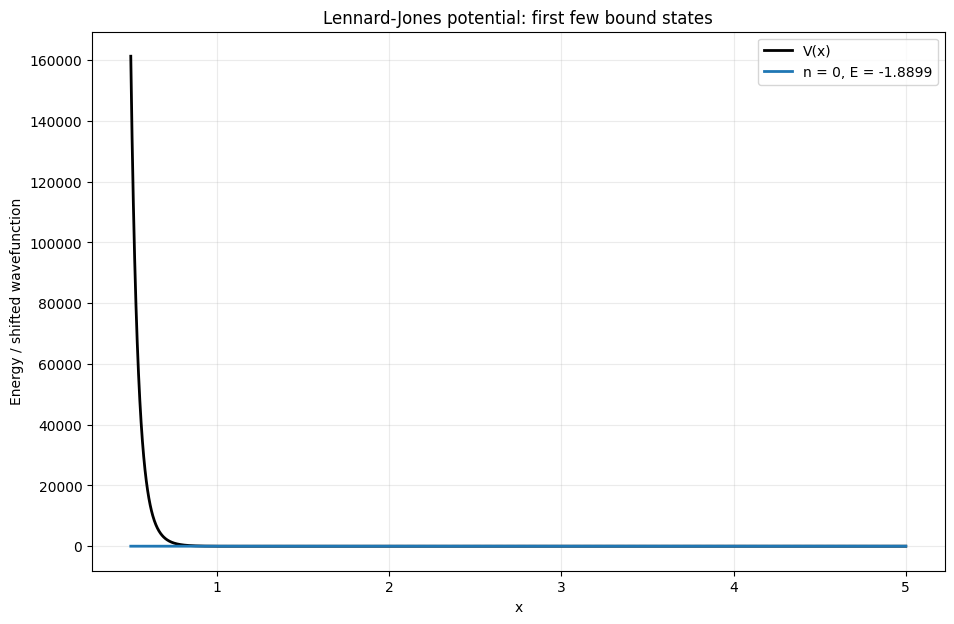

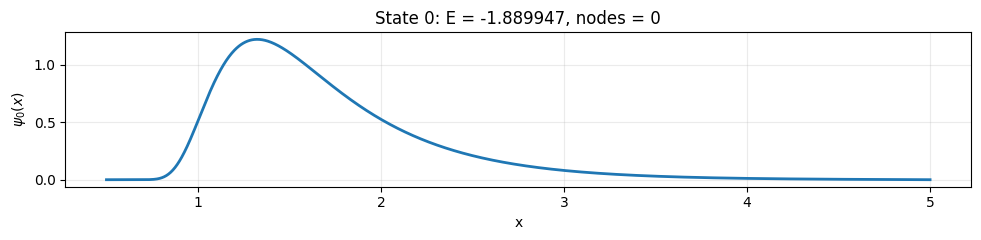

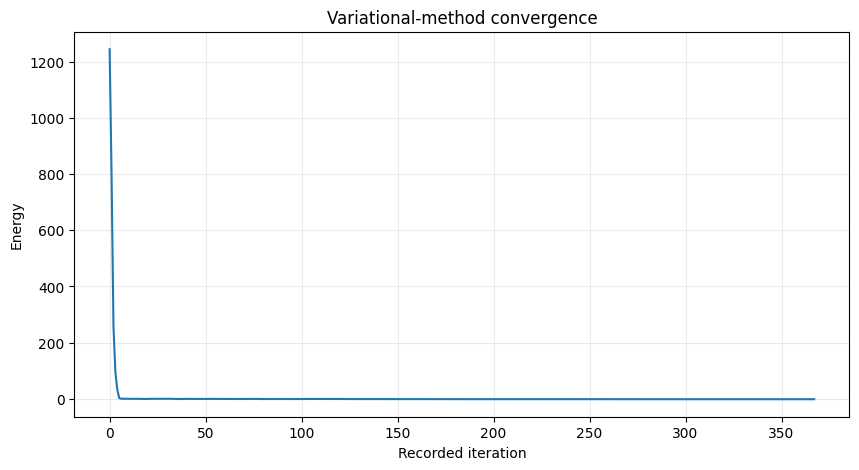

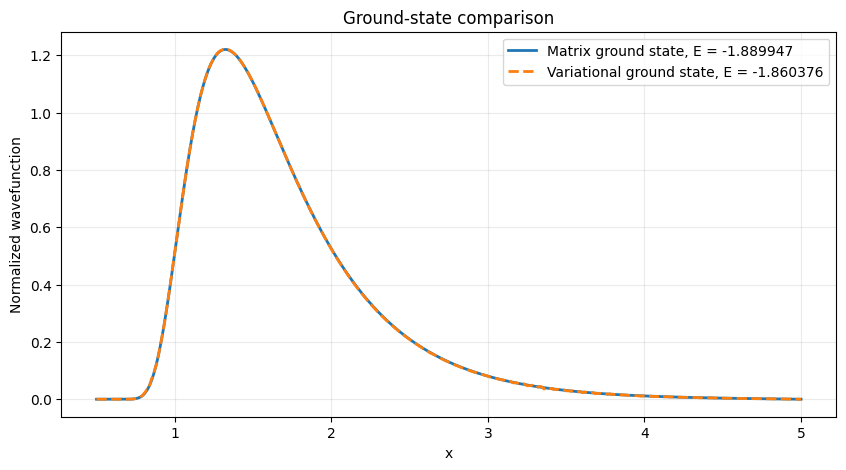

In [ ]:
# Lab 13 - Task 2

import numpy as np;
import matplotlib.pyplot as plt;


# Parameters

epsilon = 10.0;
sigma = 1.0;
# domain for the LJ problem
x_left = 0.5 * sigma;
x_right = 5.0 * sigma;
# matrix-method grid
dx_mat = 0.003;
# improved variational grid
dx_var = 0.01;
# number of bound states to report from matrix method
n_states = 4;
# plotting scale for shifted states
psi_shift_scale = 0.8;
rng = np.random.default_rng(12345);


# Lennard-Jones potential
def V_lj(x, epsilon = 10.0, sigma = 1.0):
    x = np.asarray(x, dtype = float);
    invr6 = (sigma / x) ** 6;
    return 4.0 * epsilon * (invr6**2 - invr6);


# Finite-difference matrix method
def solve_lj_matrix(epsilon, sigma, x_left, x_right, dx, n_states):
    # Interior points only, Dirichlet boundaries psi = 0 at ends
    x = np.arange(x_left, x_right + 0.5 * dx, dx);
    x = x[1:-1];
    N = len(x);
    V = V_lj(x, epsilon, sigma);
    main = 1.0 / dx**2 + V;
    off = -0.5 / dx**2 * np.ones(N - 1);
    H = np.diag(main) + np.diag(off, 1) + np.diag(off, -1);
    evals, evecs = np.linalg.eigh(H);

    # bound states only
    mask = evals < 0.0;
    evals = evals[mask];
    evecs = evecs[:, mask];
    states = [];
    n_keep = min(n_states, len(evals));

    for i in range(n_keep):
        psi_int = evecs[:, i];
        x_full = np.concatenate([[x_left], x, [x_right]]);
        psi_full = np.concatenate([[0.0], psi_int, [0.0]]);
        norm = np.sqrt(np.trapezoid(psi_full**2, x_full));
        psi_full /= norm;

        # fix sign consistently
        j = np.argmax(np.abs(psi_full));
        if psi_full[j] < 0:
            psi_full *= -1;

        # count nodes
        nodes = 0;
        prev = 0;
        thresh = 1e-10 * np.max(np.abs(psi_full));
        for val in psi_full[1:-1]:
            if abs(val) < thresh:
                continue;
            s = 1 if val > 0 else -1;
            if prev == 0:
                prev = s;
            elif s != prev:
                nodes += 1;
                prev = s;
        #endfor
        states.append({"E": evals[i], "x": x_full, "psi": psi_full, "nodes": nodes});
    #endfor
    return states;


# Improved stochastic variational method
def normalize(psi, x):
    norm = np.sqrt(np.trapezoid(psi**2, x));
    if norm > 0:
        psi /= norm;

def compute_energy(psi, x, epsilon, sigma):
    dx = x[1] - x[0];
    V = V_lj(x, epsilon, sigma);

    lap = np.zeros_like(psi);
    lap[1:-1] = (psi[2:] - 2.0 * psi[1:-1] + psi[:-2]) / dx**2;
    lap[0] = (psi[1] - 2.0 * psi[0]) / dx**2;
    lap[-1] = (psi[-2] - 2.0 * psi[-1]) / dx**2;

    integrand = -0.5 * psi * lap + V * psi**2;
    num = np.trapezoid(integrand, x);
    den = np.trapezoid(psi**2, x);
    return num / den;

def gaussian_update_profile(x, center, width):
    return np.exp(-0.5 * ((x - center) / width)**2);

def run_variational_ground_state(epsilon, sigma, x_left, x_right, dx, rng):
    x = np.arange(x_left, x_right + 0.5 * dx, dx);
    N = len(x);
    # initial trial wavefunction: smooth positive bump near LJ minimum
    x_min = 2.0**(1.0 / 6.0) * sigma;
    width0 = 0.40;
    psi = np.exp(-0.5 * ((x - x_min) / width0)**2);
    psi[0] = 0.0;
    psi[-1] = 0.0;
    normalize(psi, x);

    E = compute_energy(psi, x, epsilon, sigma);

    # Improved annealing schedule. More stages, gentler cooling, smaller late updates
    schedule = [{"steps": 3000, "amp": 0.10, "wmin": 0.06, "wmax": 0.30, "T": 0.08},
     {"steps": 3000, "amp": 0.06, "wmin": 0.05, "wmax": 0.22, "T": 0.04},
      {"steps": 3000, "amp": 0.035, "wmin": 0.04, "wmax": 0.16, "T": 0.015},
       {"steps": 3000, "amp": 0.020, "wmin": 0.03, "wmax": 0.10, "T": 0.005},
        {"steps": 3000, "amp": 0.010, "wmin": 0.025, "wmax": 0.08, "T": 0.000},
         {"steps": 3000, "amp": 0.005, "wmin": 0.020, "wmax": 0.06, "T": 0.000},];

    history = [];

    for stage_id, stage in enumerate(schedule, start = 1):
        amp = stage["amp"];
        wmin = stage["wmin"];
        wmax = stage["wmax"];
        T = stage["T"];
        accepted = 0;

        for step in range(stage["steps"]):
            psi_trial = psi.copy();
            # smooth local update
            center = rng.uniform(x_left + 0.1, x_right - 0.1);
            width = rng.uniform(wmin, wmax);
            delta = rng.uniform(-amp, amp);

            bump = gaussian_update_profile(x, center, width);
            psi_trial += delta * bump;
            # pin endpoints
            psi_trial[0] = 0.0;
            psi_trial[-1] = 0.0;
            # ground state can be chosen nonnegative; helps convergence
            psi_trial = np.abs(psi_trial);

            normalize(psi_trial, x);
            E_trial = compute_energy(psi_trial, x, epsilon, sigma);
            dE = E_trial - E;
            accept = (dE <= 0.0) or (T > 0.0 and rng.random() < np.exp(-dE / T));

            if accept:
                psi = psi_trial;
                E = E_trial;
                accepted += 1;

            if step % 50 == 0:
                history.append((len(history), E));
        #endfor
        acc_rate = accepted / stage["steps"];
        print(f"Stage {stage_id}: E = {E:.10f}, acceptance = {acc_rate:.3f}, " f"T = {T:.3f}, amp = {amp:.4f}");

    # final deterministic polishing passes, accept only downhill smooth local changes
    for sweep in range(8):
        accepted = 0;
        for _ in range(1200):
            psi_trial = psi.copy();

            center = rng.uniform(x_left + 0.1, x_right - 0.1);
            width = rng.uniform(0.02, 0.05);
            delta = rng.uniform(-0.0025, 0.0025);

            bump = gaussian_update_profile(x, center, width);
            psi_trial += delta * bump;
            psi_trial[0] = 0.0;
            psi_trial[-1] = 0.0;
            psi_trial = np.abs(psi_trial);

            normalize(psi_trial, x);
            E_trial = compute_energy(psi_trial, x, epsilon, sigma);

            if E_trial < E:
                psi = psi_trial;
                E = E_trial;
                accepted += 1;
        #endfor
        history.append((len(history), E));
        print(f"Polish {sweep+1}: E = {E:.10f}, accepted = {accepted}");
    #endfor

    # final sign convention
    j = np.argmax(np.abs(psi));
    if psi[j] < 0:
        psi *= -1;

    return {"E": E, "x": x, "psi": psi, "history": np.array(history, dtype = float)};


# Run both methods
matrix_states = solve_lj_matrix(epsilon = epsilon, sigma = sigma, x_left = x_left, x_right = x_right, dx = dx_mat, n_states = n_states);

print("\n" + "=" * 78);
print("Finite-difference matrix method: first few bound states");
print("=" * 78);
print(f"{'state':>8s} {'E_numeric':>18s} {'nodes':>10s}");
for i, st in enumerate(matrix_states):
    print(f"{i:8d} {st['E']:18.10f} {st['nodes']:10d}");
#endfor
var_state = run_variational_ground_state(epsilon = epsilon, sigma = sigma, x_left = x_left, x_right = x_right, dx = dx_var, rng = rng);

print("\n" + "=" * 78);
print("Variational method: ground state");
print("=" * 78);
print(f"Ground-state energy (variational) = {var_state['E']:.10f}");


# Compare ground states
E_mat_gs = matrix_states[0]["E"];
E_var_gs = var_state["E"];
x_mat = matrix_states[0]["x"];
psi_mat = matrix_states[0]["psi"];
x_var = var_state["x"];
psi_var = var_state["psi"];
psi_var_interp = np.interp(x_mat, x_var, psi_var);

overlap = np.trapezoid(psi_mat * psi_var_interp, x_mat);
if overlap < 0:
    psi_var_interp *= -1.0;

l2_diff = np.sqrt(np.trapezoid((psi_mat - psi_var_interp) ** 2, x_mat));

print("\n" + "=" * 78);
print("Ground-state comparison");
print("=" * 78);
print(f"Matrix-method ground state energy      = {E_mat_gs:.10f}");
print(f"Variational-method ground state energy = {E_var_gs:.10f}");
print(f"Difference (var - matrix)              = {E_var_gs - E_mat_gs:.10f}");
print(f"L2 wavefunction difference             = {l2_diff:.10f}");


# Plot potential + first few bound states
x_plot = np.linspace(x_left, x_right, 3000);
V_plot = V_lj(x_plot, epsilon, sigma);

fig, ax = plt.subplots(figsize = (11, 7));
ax.plot(x_plot, V_plot, color = 'black', lw = 2, label ='V(x)');

for i, st in enumerate(matrix_states):
    E = st["E"];
    ax.hlines(E, x_left, x_right, colors = 'gray', linestyles = 'dashed', alpha = 0.35);
    ax.plot(st["x"], E + psi_shift_scale * st["psi"], lw = 2, label = f"n = {i}, E = {E:.4f}");
#endfor
ax.set_xlabel("x");
ax.set_ylabel("Energy / shifted wavefunction");
ax.set_title("Lennard-Jones potential: first few bound states");
ax.grid(alpha = 0.25);
ax.legend();
plt.show();

# Plot individual matrix-method wavefunctions
fig, axes = plt.subplots(len(matrix_states), 1, figsize = (10, 2.5 * len(matrix_states)), sharex = True);

if len(matrix_states) == 1:
    axes = [axes];

for i, st in enumerate(matrix_states):
    axes[i].plot(st["x"], st["psi"], lw = 2);
    axes[i].set_ylabel(f"$\\psi_{i}(x)$");
    axes[i].set_title(f"State {i}: E = {st['E']:.6f}, nodes = {st['nodes']}");
    axes[i].grid(alpha = 0.25);

axes[-1].set_xlabel("x");
plt.tight_layout();
plt.show();


# Plot variational convergence
hist = var_state["history"];
fig, ax = plt.subplots(figsize = (10, 5));
ax.plot(hist[:, 0], hist[:, 1], lw = 1.5);
ax.set_xlabel("Recorded iteration");
ax.set_ylabel("Energy");
ax.set_title("Variational-method convergence");
ax.grid(alpha = 0.25);
plt.show();


# Plot ground-state comparison
fig, ax = plt.subplots(figsize = (10, 5));
ax.plot(x_mat, psi_mat, lw = 2, label = f"Matrix ground state, E = {E_mat_gs:.6f}");
ax.plot(x_mat, psi_var_interp, '--', lw = 2, label = f"Variational ground state, E = {E_var_gs:.6f}");
ax.set_xlabel("x");
ax.set_ylabel("Normalized wavefunction");
ax.set_title("Ground-state comparison");
ax.grid(alpha = 0.25);
ax.legend();
plt.show();


# EOF

